Cleared 0 old Tab 5 image file(s).

Tab 5 Final Model Configuration
  Material                  : Aluminium 6061-T6
  Process                   : spray
  Joint Type                : Lap joint
  Joint Configuration       : Double fillet weld on both longitudinal edges of the overlap
  Plate Dimensions          : 200 × 80 × 4 mm
  Overlap                   : 25 mm
  Fillet Leg                : 4 mm
  Weld Direction            : +X
  Weld Length per Pass      : 200 mm
  Weld-Line Y Positions     : [55. 80.] mm
  Weld 1 Toe Position       : Y = 51 mm
  Thermocouple Toe Distances: [ 2.  5. 10.] mm
  Nominal Duration per Pass : 25.000 s
  Nominal Total Duration    : 50.000 s
  Monte Carlo Samples       : 100


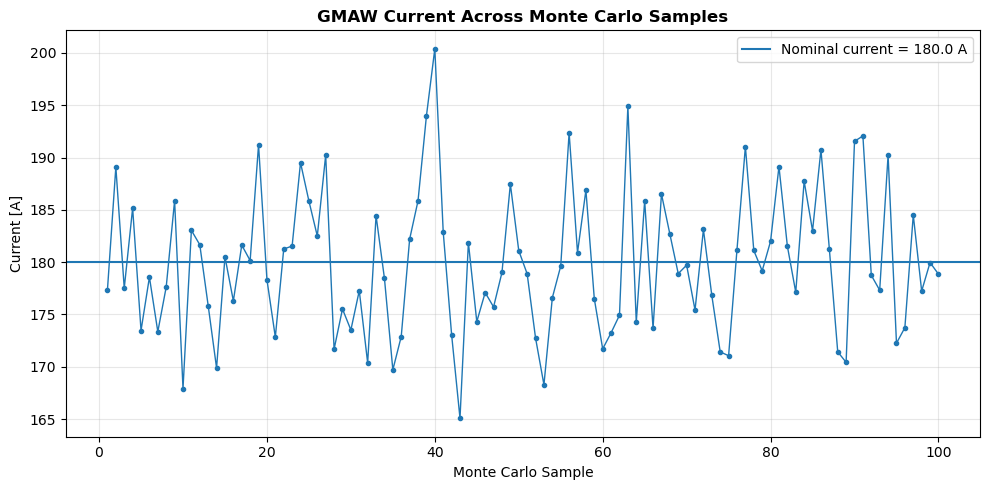

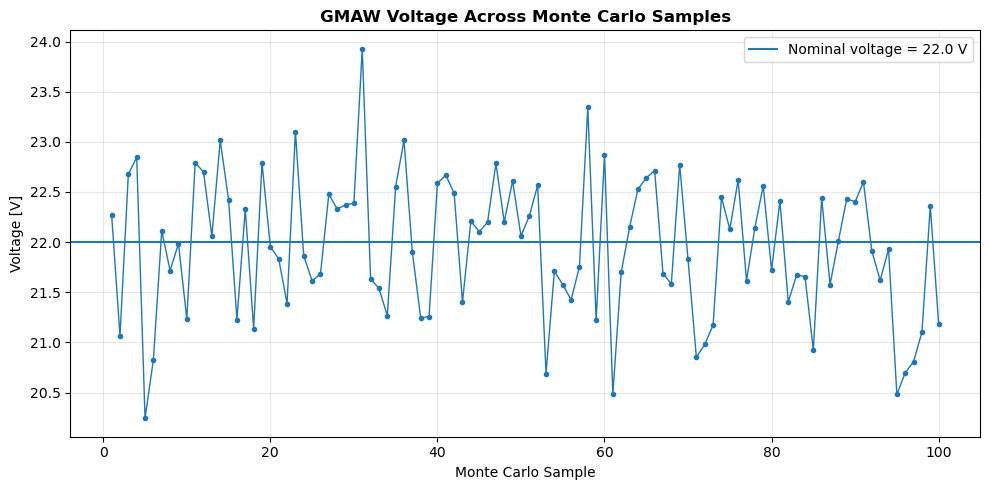

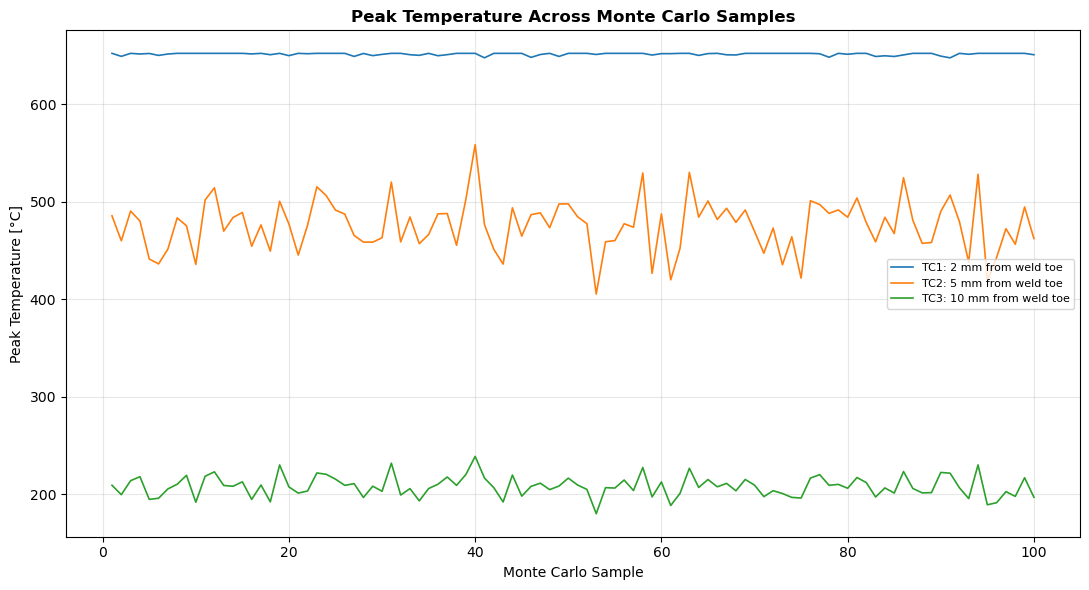

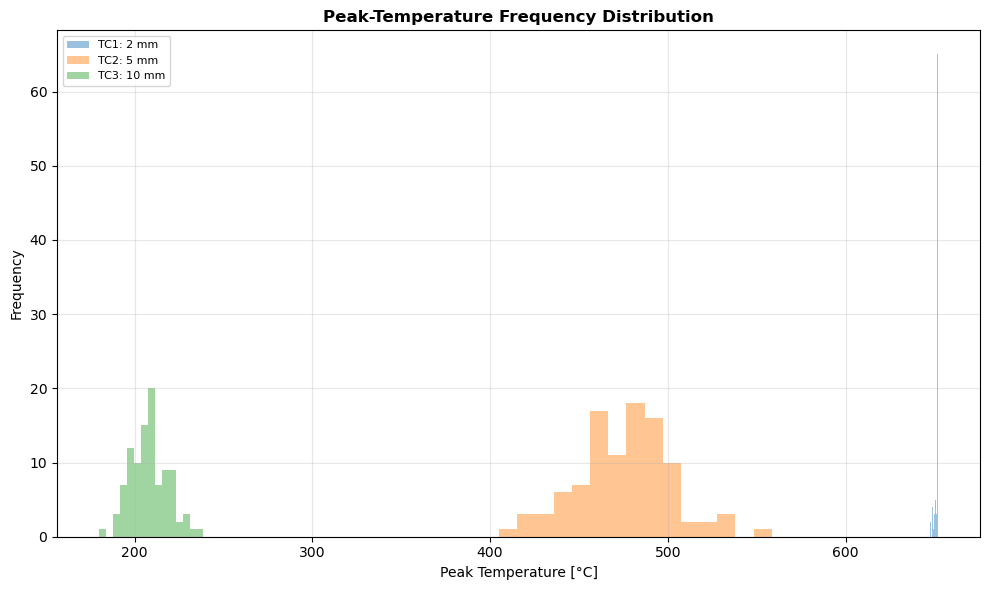

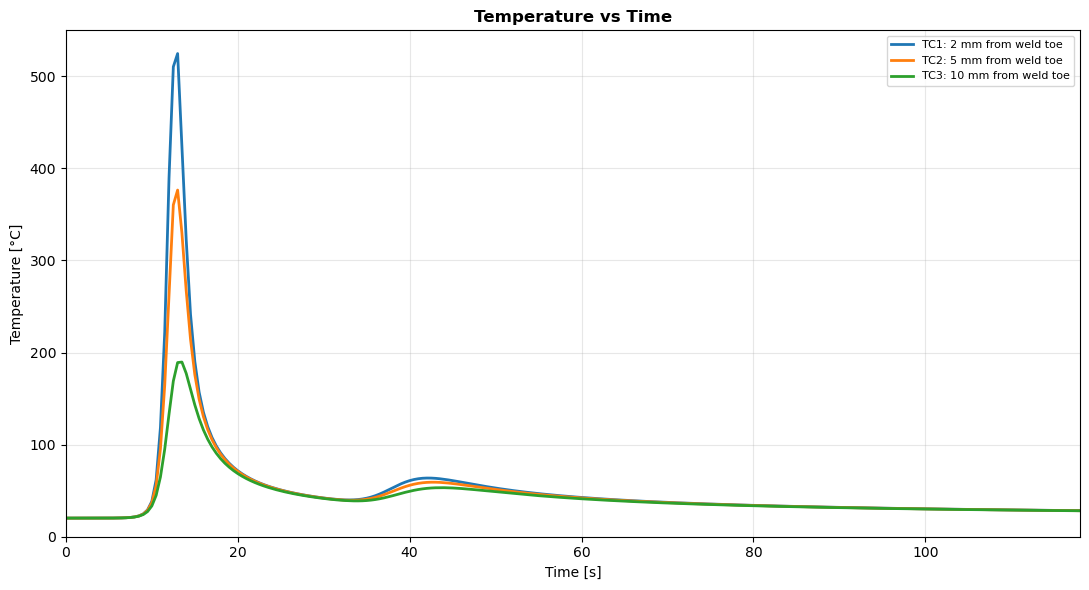

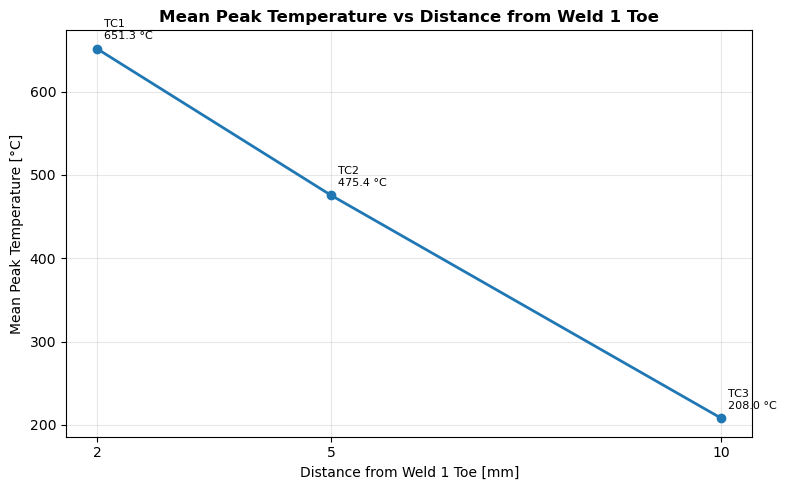

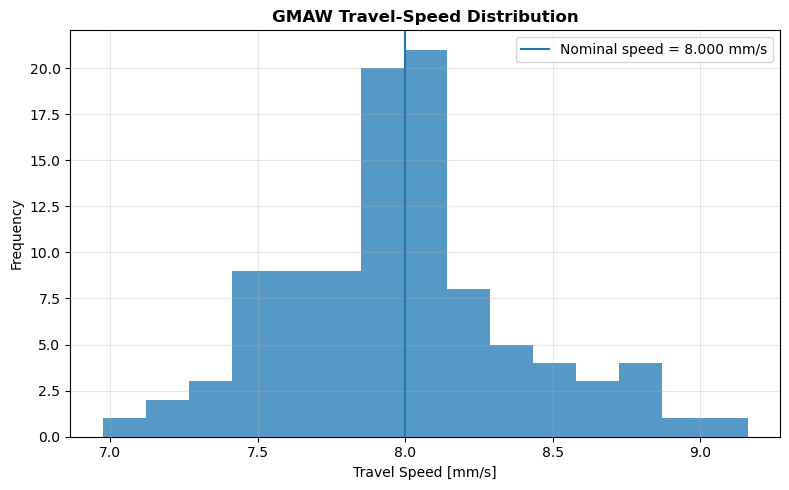

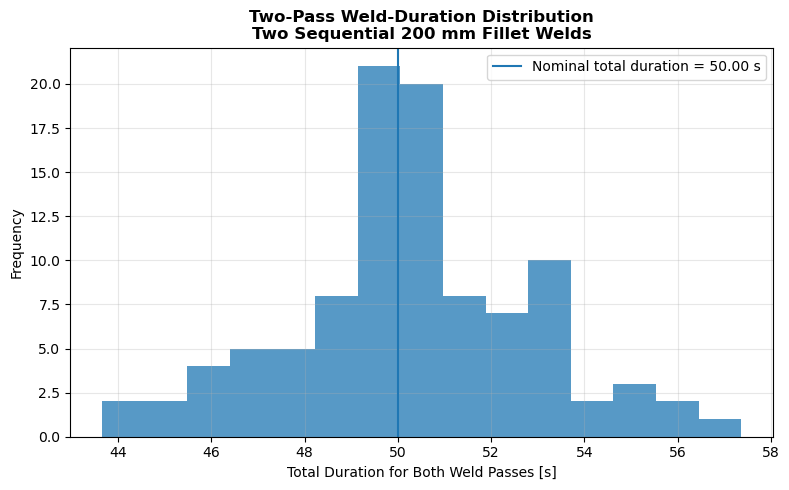


THERMAL ANALYSIS SUMMARY

Process
  Base Process          : spray
  Manufacturer          : Generic GMAW System
  Power Source          : Constant Voltage Power Source
  Shielding Gas         : 98% Ar / 2% CO2
  Voltage               : [22.0] V
  Current               : [180.0] A
  Wire Feed Rate        : [7.0] m / min

Material: Aluminium 6061-T6
  Thermal Conductivity  : 167.00 W/m/K
  Density               : 2700 kg/m³
  Specific Heat         : 896 J/kg/K
  Thermal Diffusivity   : 6.903e-05 m²/s
  Melting Point         : 652.0 °C

Peak-Temperature Statistics
  TC1 at 2 mm from weld toe: mean=651.3 °C, std=1.2 °C, min=647.4 °C, max=652.0 °C
  TC2 at 5 mm from weld toe: mean=475.4 °C, std=26.5 °C, min=405.2 °C, max=558.4 °C
  TC3 at 10 mm from weld toe: mean=208.0 °C, std=10.5 °C, min=179.9 °C, max=238.7 °C

Generated File Check
  ✓ plot1_current.png
  ✓ plot2_voltage.png
  ✓ plot3_peak_temperature_vs_sample.png
  ✓ plot4_peak_temperature_frequency.png
  ✓ plot5_temperature_vs_time.p

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from weldx import WeldxFile, Q_


# ============================================================
# PROJECT FILE
# ============================================================
CORE_FILE = "project_core.asdf"

if not Path(CORE_FILE).exists():
    raise FileNotFoundError(
        f"⚠ {CORE_FILE} not found. "
        "Run corrected Tabs 1 to 4 first!"
    )


# ============================================================
# LOAD SHARED PROJECT DATA
# ============================================================
with WeldxFile(CORE_FILE, mode="r") as wx:
    core = wx.copy()


required_keys = [
    "material",
    "geometry",
    "gmaw_process",
    "process",
    "monte_carlo",
    "thermal_results",
]

missing_keys = [
    key
    for key in required_keys
    if key not in core
]

if missing_keys:
    raise KeyError(
        f"Missing required data in {CORE_FILE}: {missing_keys}. "
        "Run corrected Tabs 1 to 4 again in order."
    )


material_core = core["material"]
geometry_core = core["geometry"]
gmaw_process = core["gmaw_process"]
mc_raw = core["monte_carlo"]
thermal_raw = core["thermal_results"]


# ============================================================
# MATERIAL AND FINAL JOINT GEOMETRY
# ============================================================
material_name = str(
    material_core["common_name"]
)

joint_type = str(
    geometry_core["joint_type"]
)

joint_configuration = str(
    geometry_core["joint_configuration"]
)

plate_length_mm = float(
    geometry_core["plate_length"]
    .to("mm")
    .m
)

plate_width_mm = float(
    geometry_core["plate_width"]
    .to("mm")
    .m
)

plate_thickness_mm = float(
    geometry_core["plate_thickness"]
    .to("mm")
    .m
)

overlap_mm = float(
    geometry_core["overlap"]
    .to("mm")
    .m
)

fillet_leg_mm = float(
    geometry_core["fillet_leg"]
    .to("mm")
    .m
)

weld_length_mm = float(
    geometry_core["weld_length"]
    .to("mm")
    .m
)

weld_line_y_mm = np.asarray(
    geometry_core["weld_line_y_positions"]
    .to("mm")
    .m,
    dtype=float,
)

weld_1_toe_y_mm = float(
    thermal_raw["weld_1_toe_y"]
    .to("mm")
    .m
)


# ============================================================
# VERIFY THE FINAL CONFIGURATION
# ============================================================
expected_values = {
    "plate length": (
        plate_length_mm,
        200.0,
    ),
    "plate width": (
        plate_width_mm,
        80.0,
    ),
    "plate thickness": (
        plate_thickness_mm,
        4.0,
    ),
    "overlap": (
        overlap_mm,
        25.0,
    ),
    "fillet leg": (
        fillet_leg_mm,
        4.0,
    ),
    "weld length": (
        weld_length_mm,
        200.0,
    ),
    "Weld 1 toe position": (
        weld_1_toe_y_mm,
        51.0,
    ),
}

for name, (
    actual_value,
    expected_value,
) in expected_values.items():
    if not np.isclose(
        actual_value,
        expected_value,
        rtol=0.0,
        atol=1.0e-9,
    ):
        raise ValueError(
            f"Unexpected {name}: {actual_value} mm. "
            f"Expected {expected_value} mm."
        )


if geometry_core["weld_travel_direction"] != "+x":
    raise ValueError(
        "Tab 5 requires the weld direction to be +X."
    )


if not np.allclose(
    weld_line_y_mm,
    np.array(
        [
            55.0,
            80.0,
        ]
    ),
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "The weld lines must be at Y = 55 mm and Y = 80 mm."
    )


# ============================================================
# MONTE CARLO DATA FROM TAB 2
# ============================================================
N = int(
    mc_raw["n_samples"]
)

sample_numbers = np.arange(
    1,
    N + 1,
)

mc_voltage_V = np.asarray(
    mc_raw["voltage"]
    .to("V")
    .m,
    dtype=float,
)

mc_current_A = np.asarray(
    mc_raw["current"]
    .to("A")
    .m,
    dtype=float,
)

mc_speed_mm_s = np.asarray(
    mc_raw["speed"]
    .to("mm/s")
    .m,
    dtype=float,
)

mc_net_power_W = np.asarray(
    mc_raw["net_power"]
    .to("W")
    .m,
    dtype=float,
)

mc_heat_input_J_m = np.asarray(
    mc_raw["heat_input"]
    .to("J/m")
    .m,
    dtype=float,
)

nominal_voltage_V = float(
    mc_raw["nominal_voltage"]
    .to("V")
    .m
)

nominal_current_A = float(
    mc_raw["nominal_current"]
    .to("A")
    .m
)

nominal_speed_mm_s = float(
    mc_raw["nominal_speed"]
    .to("mm/s")
    .m
)


# ============================================================
# THERMAL DATA FROM THE FINAL TAB 4
# ============================================================
thermal_sample_count = int(
    thermal_raw["n_samples"]
)

if thermal_sample_count != N:
    raise ValueError(
        "The Monte Carlo and thermal sample counts do not match."
    )


time_s = np.asarray(
    thermal_raw["t_array"]
    .to("s")
    .m,
    dtype=float,
)

sensor_labels = [
    str(label)
    for label in thermal_raw["sensor_labels"]
]

sensor_distances_mm = np.asarray(
    thermal_raw["sensor_distances_mm"]
    .to("mm")
    .m,
    dtype=float,
)

sensor_x_mm = np.asarray(
    thermal_raw["sensor_x_positions"]
    .to("mm")
    .m,
    dtype=float,
)

sensor_y_mm = np.asarray(
    thermal_raw["sensor_y_positions"]
    .to("mm")
    .m,
    dtype=float,
)

sensor_z_mm = np.asarray(
    thermal_raw["sensor_z_positions"]
    .to("mm")
    .m,
    dtype=float,
)

thermal_results_degC = {
    str(label): np.asarray(
        values.to("degC").m,
        dtype=float,
    )
    for label, values
    in thermal_raw["thermal_results"].items()
}

peak_temperatures_degC = {
    str(label): np.asarray(
        values.to("degC").m,
        dtype=float,
    )
    for label, values
    in thermal_raw["peak_temperatures"].items()
}

peak_times_s = {
    str(label): np.asarray(
        values.to("s").m,
        dtype=float,
    )
    for label, values
    in thermal_raw["peak_times"].items()
}


if not np.allclose(
    sensor_distances_mm,
    np.array(
        [
            2.0,
            5.0,
            10.0,
        ]
    ),
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "The thermocouples must be 2 mm, 5 mm and 10 mm "
        "from the Weld 1 toe."
    )


expected_sensor_y_mm = (
    weld_1_toe_y_mm
    - sensor_distances_mm
)

if not np.allclose(
    sensor_y_mm,
    expected_sensor_y_mm,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "The thermocouple coordinates do not match distances "
        "from the Weld 1 toe."
    )


for label in sensor_labels:
    if label not in thermal_results_degC:
        raise KeyError(
            f"Missing thermal results for {label}."
        )

    if label not in peak_temperatures_degC:
        raise KeyError(
            f"Missing peak-temperature results for {label}."
        )

    if thermal_results_degC[label].shape != (
        N,
        len(time_s),
    ):
        raise ValueError(
            f"Unexpected thermal-result shape for {label}: "
            f"{thermal_results_degC[label].shape}."
        )


# ============================================================
# TWO-PASS WELD DURATION
# ============================================================
duration_per_pass_s = (
    weld_length_mm
    / mc_speed_mm_s
)

total_two_pass_duration_s = (
    2.0
    * duration_per_pass_s
)

nominal_duration_per_pass_s = (
    weld_length_mm
    / nominal_speed_mm_s
)

nominal_total_two_pass_duration_s = (
    2.0
    * nominal_duration_per_pass_s
)


# ============================================================
# REMOVE OLD TAB 5 FIGURES
# ============================================================
output_files = [
    "plot1_current.png",
    "plot2_voltage.png",
    "plot3_peak_temperature_vs_sample.png",
    "plot4_peak_temperature_frequency.png",
    "plot5_temperature_vs_time.png",
    "plot6_peak_temperature_vs_toe_distance.png",
    "plot7_travel_speed_distribution.png",
    "plot8_two_pass_duration_distribution.png",
]

obsolete_files = [
    "plot1_current_voltage.png",
    "plot2_sensor_vs_sample.png",
    "plot3_temp_frequency.png",
    "figure4a_thermal_cycles.png",
    "figure4b_temperature_profile.png",
    "figure5a_travel_speed_distribution.png",
    "figure5c_weld_duration_distribution.png",
    "figure5d_nominal_thermal_cycles.png",
]

removed = 0

for file_name in (
    output_files
    + obsolete_files
):
    file_path = Path(
        file_name
    )

    if file_path.exists():
        file_path.unlink()
        removed += 1

plt.close(
    "all"
)

print(
    f"Cleared {removed} old Tab 5 image file(s)."
)


# ============================================================
# MODEL SUMMARY
# ============================================================
print("\nTab 5 Final Model Configuration")

print(
    f"  Material                  : {material_name}"
)

print(
    f"  Process                   : {gmaw_process.base_process}"
)

print(
    f"  Joint Type                : {joint_type}"
)

print(
    f"  Joint Configuration       : {joint_configuration}"
)

print(
    f"  Plate Dimensions          : "
    f"{plate_length_mm:.0f} × "
    f"{plate_width_mm:.0f} × "
    f"{plate_thickness_mm:.0f} mm"
)

print(
    f"  Overlap                   : {overlap_mm:.0f} mm"
)

print(
    f"  Fillet Leg                : {fillet_leg_mm:.0f} mm"
)

print(
    f"  Weld Direction            : +X"
)

print(
    f"  Weld Length per Pass      : {weld_length_mm:.0f} mm"
)

print(
    f"  Weld-Line Y Positions     : {weld_line_y_mm} mm"
)

print(
    f"  Weld 1 Toe Position       : Y = {weld_1_toe_y_mm:.0f} mm"
)

print(
    f"  Thermocouple Toe Distances: {sensor_distances_mm} mm"
)

print(
    f"  Nominal Duration per Pass : "
    f"{nominal_duration_per_pass_s:.3f} s"
)

print(
    f"  Nominal Total Duration    : "
    f"{nominal_total_two_pass_duration_s:.3f} s"
)

print(
    f"  Monte Carlo Samples       : {N}"
)


# ============================================================
# PLOT 1: CURRENT VS MONTE CARLO SAMPLE
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

ax.plot(
    sample_numbers,
    mc_current_A,
    marker="o",
    markersize=3,
    linewidth=1.0,
)

ax.axhline(
    nominal_current_A,
    linewidth=1.5,
    label=(
        f"Nominal current = "
        f"{nominal_current_A:.1f} A"
    ),
)

ax.set_title(
    "GMAW Current Across Monte Carlo Samples",
    fontweight="bold",
)

ax.set_xlabel(
    "Monte Carlo Sample"
)

ax.set_ylabel(
    "Current [A]"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "plot1_current.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 2: VOLTAGE VS MONTE CARLO SAMPLE
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

ax.plot(
    sample_numbers,
    mc_voltage_V,
    marker="o",
    markersize=3,
    linewidth=1.0,
)

ax.axhline(
    nominal_voltage_V,
    linewidth=1.5,
    label=(
        f"Nominal voltage = "
        f"{nominal_voltage_V:.1f} V"
    ),
)

ax.set_title(
    "GMAW Voltage Across Monte Carlo Samples",
    fontweight="bold",
)

ax.set_xlabel(
    "Monte Carlo Sample"
)

ax.set_ylabel(
    "Voltage [V]"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "plot2_voltage.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 3: PEAK TEMPERATURE VS SAMPLE
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        11,
        6,
    )
)

for label, distance_mm in zip(
    sensor_labels,
    sensor_distances_mm,
):
    ax.plot(
        sample_numbers,
        peak_temperatures_degC[
            label
        ],
        linewidth=1.2,
        label=(
            f"{label}: "
            f"{distance_mm:.0f} mm from weld toe"
        ),
    )

ax.set_title(
    "Peak Temperature Across Monte Carlo Samples",
    fontweight="bold",
)

ax.set_xlabel(
    "Monte Carlo Sample"
)

ax.set_ylabel(
    "Peak Temperature [°C]"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "plot3_peak_temperature_vs_sample.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 4: PEAK-TEMPERATURE FREQUENCY
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        10,
        6,
    )
)

for label, distance_mm in zip(
    sensor_labels,
    sensor_distances_mm,
):
    ax.hist(
        peak_temperatures_degC[
            label
        ],
        bins=15,
        alpha=0.45,
        label=(
            f"{label}: "
            f"{distance_mm:.0f} mm"
        ),
    )

ax.set_title(
    "Peak-Temperature Frequency Distribution",
    fontweight="bold",
)

ax.set_xlabel(
    "Peak Temperature [°C]"
)

ax.set_ylabel(
    "Frequency"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "plot4_peak_temperature_frequency.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 5: TEMPERATURE VS TIME ONLY
# ============================================================
# No individual weld contribution curves.
# No nominal-cycle overlay.
# No percentile shading.
# No torch-position lines.
# No t500/300 lines.

fig, ax = plt.subplots(
    figsize=(
        11,
        6,
    )
)

mean_temperature_cycles_degC = {}

for label, distance_mm in zip(
    sensor_labels,
    sensor_distances_mm,
):
    mean_cycle_degC = thermal_results_degC[
        label
    ].mean(
        axis=0
    )

    mean_temperature_cycles_degC[
        label
    ] = mean_cycle_degC

    ax.plot(
        time_s,
        mean_cycle_degC,
        linewidth=2.0,
        label=(
            f"{label}: "
            f"{distance_mm:.0f} mm from weld toe"
        ),
    )

ax.set_title(
    "Temperature vs Time",
    fontweight="bold",
)

ax.set_xlabel(
    "Time [s]"
)

ax.set_ylabel(
    "Temperature [°C]"
)

ax.set_xlim(
    float(
        time_s.min()
    ),
    float(
        time_s.max()
    ),
)

ax.set_ylim(
    bottom=0.0,
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "plot5_temperature_vs_time.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 6: MEAN PEAK TEMPERATURE VS WELD-TOE DISTANCE
# ============================================================
mean_peak_temperatures_degC = np.asarray(
    [
        peak_temperatures_degC[
            label
        ].mean()
        for label
        in sensor_labels
    ],
    dtype=float,
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    sensor_distances_mm,
    mean_peak_temperatures_degC,
    marker="o",
    linewidth=2.0,
)

for (
    distance_mm,
    mean_peak_degC,
    label,
) in zip(
    sensor_distances_mm,
    mean_peak_temperatures_degC,
    sensor_labels,
):
    ax.annotate(
        (
            f"{label}\n"
            f"{mean_peak_degC:.1f} °C"
        ),
        xy=(
            distance_mm,
            mean_peak_degC,
        ),
        xytext=(
            5,
            7,
        ),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(
    "Mean Peak Temperature vs Distance from Weld 1 Toe",
    fontweight="bold",
)

ax.set_xlabel(
    "Distance from Weld 1 Toe [mm]"
)

ax.set_ylabel(
    "Mean Peak Temperature [°C]"
)

ax.set_xticks(
    sensor_distances_mm
)

ax.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    "plot6_peak_temperature_vs_toe_distance.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 7: TRAVEL-SPEED DISTRIBUTION
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.hist(
    mc_speed_mm_s,
    bins=15,
    alpha=0.75,
)

ax.axvline(
    nominal_speed_mm_s,
    linewidth=1.5,
    label=(
        f"Nominal speed = "
        f"{nominal_speed_mm_s:.3f} mm/s"
    ),
)

ax.set_title(
    "GMAW Travel-Speed Distribution",
    fontweight="bold",
)

ax.set_xlabel(
    "Travel Speed [mm/s]"
)

ax.set_ylabel(
    "Frequency"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "plot7_travel_speed_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 8: TOTAL DURATION FOR TWO 200 MM WELD PASSES
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.hist(
    total_two_pass_duration_s,
    bins=15,
    alpha=0.75,
)

ax.axvline(
    nominal_total_two_pass_duration_s,
    linewidth=1.5,
    label=(
        f"Nominal total duration = "
        f"{nominal_total_two_pass_duration_s:.2f} s"
    ),
)

ax.set_title(
    (
        "Two-Pass Weld-Duration Distribution\n"
        "Two Sequential 200 mm Fillet Welds"
    ),
    fontweight="bold",
)

ax.set_xlabel(
    "Total Duration for Both Weld Passes [s]"
)

ax.set_ylabel(
    "Frequency"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "plot8_two_pass_duration_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# NUMERICAL SUMMARY
# ============================================================
print("\nTHERMAL ANALYSIS SUMMARY")

print("\nProcess")

print(
    f"  Base Process          : {gmaw_process.base_process}"
)

print(
    f"  Manufacturer          : {gmaw_process.manufacturer}"
)

print(
    f"  Power Source          : {gmaw_process.power_source}"
)

print(
    f"  Shielding Gas         : "
    f"{gmaw_process.meta.get('shielding_gas', 'N/A')}"
)

print(
    f"  Voltage               : "
    f"{gmaw_process.parameters['voltage'].data}"
)

print(
    f"  Current               : "
    f"{gmaw_process.parameters['current'].data}"
)

print(
    f"  Wire Feed Rate        : "
    f"{gmaw_process.parameters['wire_feedrate'].data}"
)


print(f"\nMaterial: {material_name}")

print(
    f"  Thermal Conductivity  : "
    f"{float(thermal_raw['material']['thermal_conductivity'].to('W/m/K').m):.2f} "
    "W/m/K"
)

print(
    f"  Density               : "
    f"{float(thermal_raw['material']['density'].to('kg/m^3').m):.0f} "
    "kg/m³"
)

print(
    f"  Specific Heat         : "
    f"{float(thermal_raw['material']['specific_heat'].to('J/kg/K').m):.0f} "
    "J/kg/K"
)

print(
    f"  Thermal Diffusivity   : "
    f"{float(thermal_raw['material']['thermal_diffusivity'].to('m^2/s').m):.3e} "
    "m²/s"
)

print(
    f"  Melting Point         : "
    f"{float(thermal_raw['material']['melting_point'].to('degC').m):.1f} °C"
)


print("\nPeak-Temperature Statistics")

for label, distance_mm in zip(
    sensor_labels,
    sensor_distances_mm,
):
    peak_values_degC = peak_temperatures_degC[
        label
    ]

    print(
        f"  {label} at {distance_mm:.0f} mm from weld toe: "
        f"mean={peak_values_degC.mean():.1f} °C, "
        f"std={peak_values_degC.std():.1f} °C, "
        f"min={peak_values_degC.min():.1f} °C, "
        f"max={peak_values_degC.max():.1f} °C"
    )


# ============================================================
# STORE TAB 5 ANALYSIS SUMMARY
# ============================================================
analysis_summary = {
    "data_source": (
        "Post-processing of the final Al6061 double-fillet "
        "lap-joint Monte Carlo and Rosenthal results. "
        "Both welds are 200 mm long and travel along +X. "
        "Thermocouple distances are measured from the "
        "outer end/toe of the Weld 1 horizontal leg."
    ),

    "material": (
        material_name
    ),

    "joint_type": (
        joint_type
    ),

    "joint_configuration": (
        joint_configuration
    ),

    "weld_direction": (
        "+x"
    ),

    "weld_length_per_pass": Q_(
        weld_length_mm,
        "mm",
    ),

    "weld_line_y_positions": Q_(
        weld_line_y_mm,
        "mm",
    ),

    "weld_1_toe_y": Q_(
        weld_1_toe_y_mm,
        "mm",
    ),

    "sensor_labels": (
        sensor_labels
    ),

    "sensor_distances_from_weld_1_toe": Q_(
        sensor_distances_mm,
        "mm",
    ),

    "sensor_positions": {
        "x": Q_(
            sensor_x_mm,
            "mm",
        ),
        "y": Q_(
            sensor_y_mm,
            "mm",
        ),
        "z": Q_(
            sensor_z_mm,
            "mm",
        ),
    },

    "n_samples": (
        N
    ),

    "nominal_duration_per_pass": Q_(
        nominal_duration_per_pass_s,
        "s",
    ),

    "nominal_total_two_pass_duration": Q_(
        nominal_total_two_pass_duration_s,
        "s",
    ),

    "mean_peak_temperatures": {
        label: Q_(
            float(
                peak_temperatures_degC[
                    label
                ].mean()
            ),
            "degC",
        )
        for label
        in sensor_labels
    },

    "mean_peak_times": {
        label: Q_(
            float(
                peak_times_s[
                    label
                ].mean()
            ),
            "s",
        )
        for label
        in sensor_labels
    },

    "temperature_vs_time_data": {
        "time": Q_(
            time_s,
            "s",
        ),
        "mean_temperature_cycles": {
            label: Q_(
                mean_temperature_cycles_degC[
                    label
                ],
                "degC",
            )
            for label
            in sensor_labels
        },
    },

    "output_images": {
        "current": (
            "plot1_current.png"
        ),
        "voltage": (
            "plot2_voltage.png"
        ),
        "peak_temperature_vs_sample": (
            "plot3_peak_temperature_vs_sample.png"
        ),
        "peak_temperature_frequency": (
            "plot4_peak_temperature_frequency.png"
        ),
        "temperature_vs_time": (
            "plot5_temperature_vs_time.png"
        ),
        "peak_temperature_vs_toe_distance": (
            "plot6_peak_temperature_vs_toe_distance.png"
        ),
        "travel_speed_distribution": (
            "plot7_travel_speed_distribution.png"
        ),
        "two_pass_duration_distribution": (
            "plot8_two_pass_duration_distribution.png"
        ),
    },
}


with WeldxFile(
    CORE_FILE,
    mode="rw",
) as wx:
    wx["analysis_summary"] = (
        analysis_summary
    )


# ============================================================
# GENERATED FILE CHECK
# ============================================================
print("\nGenerated File Check")

for file_name in output_files:
    status = (
        "✓"
        if Path(file_name).exists()
        else "✗"
    )

    print(
        f"  {status} {file_name}"
    )


print(
    "\nTab 5 completed successfully."
)